In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/predict-loan-default/train.csv
/kaggle/input/competitions/predict-loan-default/test.csv
/kaggle/input/competitions/predict-loan-default/sample_submmission.csv


# Load the data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/predict-loan-default/train.csv")
test = pd.read_csv("/kaggle/input/competitions/predict-loan-default/test.csv")

# EDA

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176400 entries, 0 to 176399
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 176400 non-null  int64 
 1   Income             176400 non-null  int64 
 2   Age                176400 non-null  int64 
 3   Experience         176400 non-null  int64 
 4   Married.Single     176400 non-null  object
 5   House_Ownership    176400 non-null  object
 6   Car_Ownership      176400 non-null  object
 7   Profession         176400 non-null  object
 8   CITY               176400 non-null  object
 9   STATE              176400 non-null  object
 10  CURRENT_JOB_YRS    176400 non-null  int64 
 11  CURRENT_HOUSE_YRS  176400 non-null  int64 
 12  Risk_Flag          176400 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 17.5+ MB


In [18]:
train['Risk_Flag'].value_counts()
train['Risk_Flag'].value_counts(normalize=True)

Risk_Flag
0    0.877234
1    0.122766
Name: proportion, dtype: float64

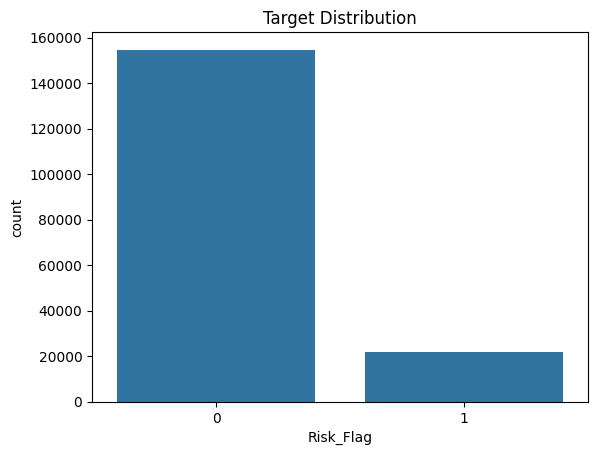

In [19]:
sns.countplot(x='Risk_Flag', data=train)
plt.title("Target Distribution")
plt.show()

* Distribution plots

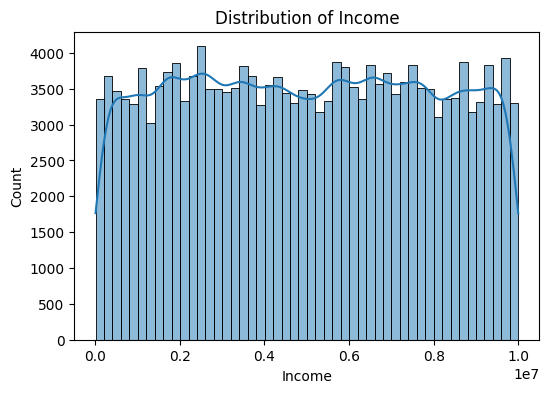

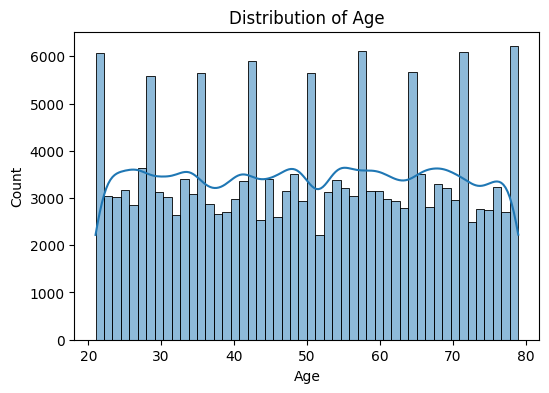

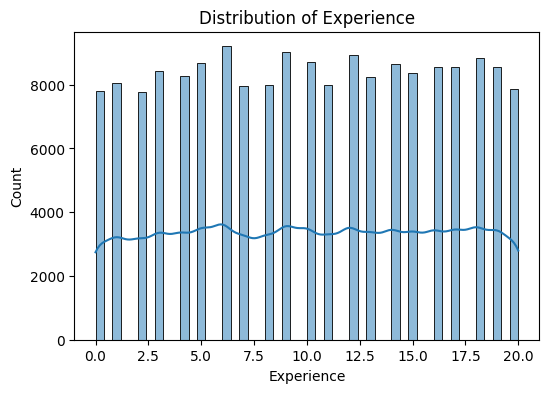

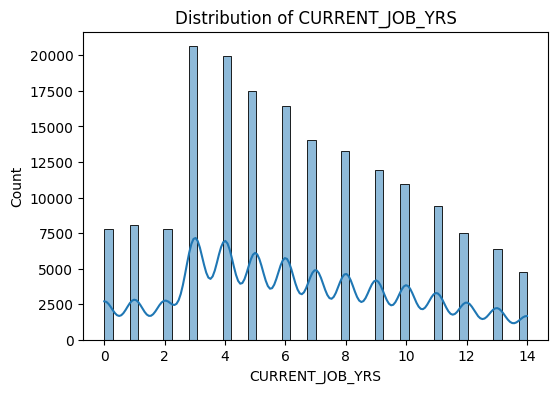

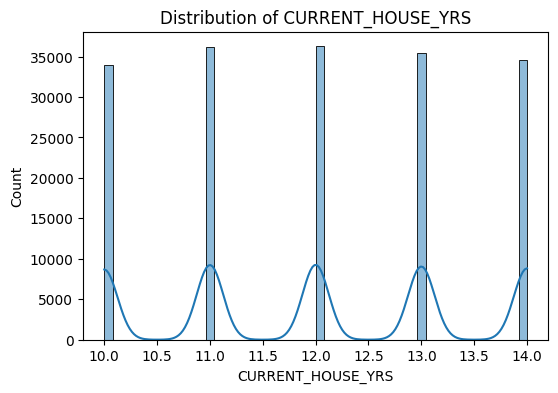

In [20]:
num_cols = [
    'Income', 'Age', 'Experience',
    'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(train[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

* Compair num features to target

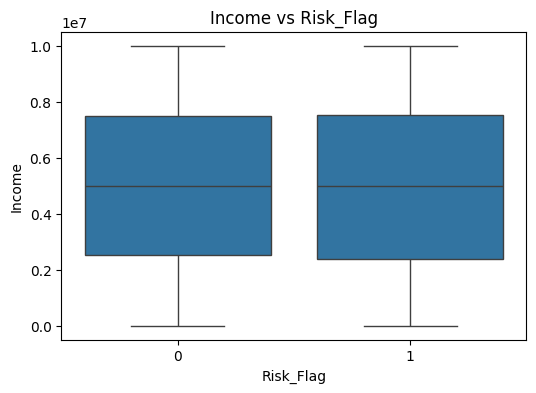

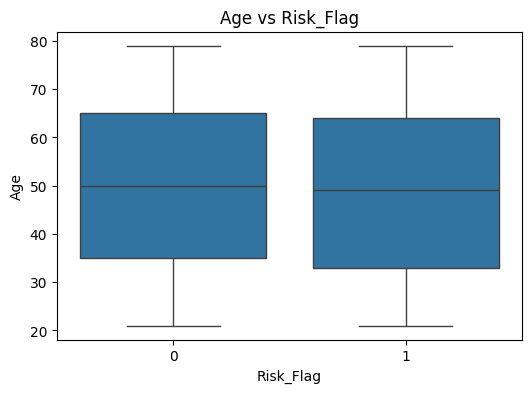

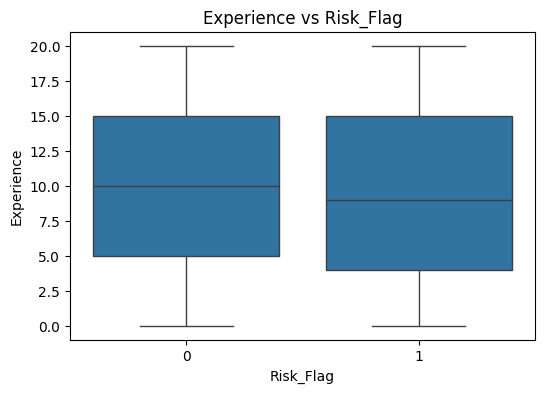

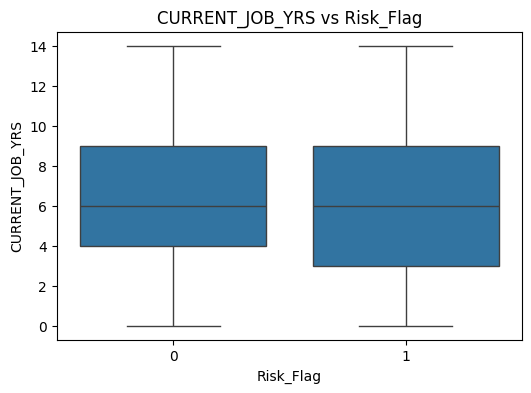

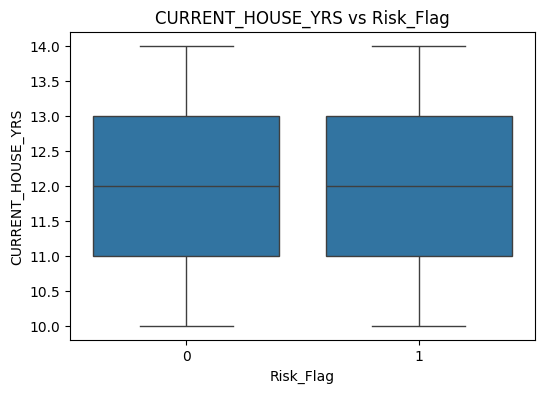

In [21]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Risk_Flag', y=col, data=train)
    plt.title(f"{col} vs Risk_Flag")
    plt.show()

* Correlation matrix

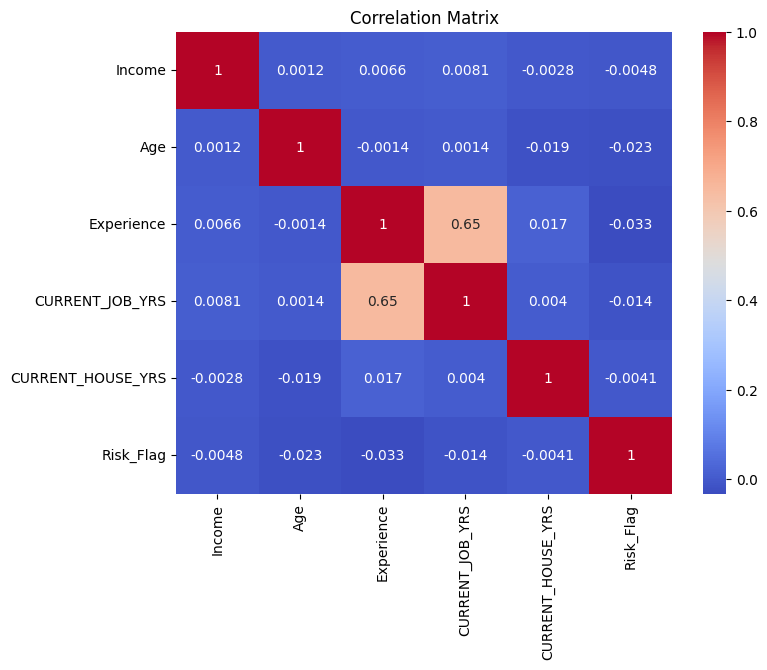

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols + ['Risk_Flag']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

In [3]:
# Save IDs
test_ids = test["Id"]

# Drop ID
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

In [12]:
def feature_Engineering(df):
    df['Low_Income_Flag'] = (df['Income'] < df['Income'].median()).astype(int)
    df['Low_Experience_Flag'] = (df['Experience'] < 3).astype(int)
    df['Short_Job_Flag'] = (df['CURRENT_JOB_YRS'] < 2).astype(int)

    # interaction
    df['Job_Switch_Rate'] = df['Experience'] - df['CURRENT_JOB_YRS']
    df['Job_Loyalty_Ratio'] = df['CURRENT_JOB_YRS'] / (df['Experience'] + 1)

    # renters defaults more
    df['Renter_LowIncome'] = (
    (df['House_Ownership'] == 'Rented') &
    (df['Income'] < df['Income'].median())).astype(int)

    # single people default more 
    df['Single_LowStability'] = (
    (df['Married.Single'] == 'Single') &
    (df['CURRENT_JOB_YRS'] < 2)).astype(int)

    # Age groups sometimes helps
    df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60, 100],
    labels=[0,1,2,3,4])

    # stability
    df['Income_per_Experience'] = df['Income'] / (df['Experience'] + 1)
    df['Income_per_Age'] = df['Income'] / (df['Age'] + 1)
    df['Job_Stability'] = df['CURRENT_JOB_YRS'] / (df['Experience'] + 1)
    df['House_Stability'] = df['CURRENT_HOUSE_YRS'] / (df['Age'] + 1)
    df['Total_Stability'] = df['CURRENT_JOB_YRS'] + df['CURRENT_HOUSE_YRS']
    return df

In [13]:
train = feature_Engineering(train)
test = feature_Engineering(test)

In [14]:
train.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False)
train.groupby('STATE')['Risk_Flag'].mean().sort_values(ascending=False)
train.groupby('CITY')['Risk_Flag'].mean().sort_values(ascending=False)

CITY
Bhubaneswar        0.339450
Bettiah[33]        0.273885
Gwalior            0.263158
Kochi              0.261725
Barasat            0.252971
                     ...   
Bijapur            0.034121
Gandhinagar        0.033784
Rajpur_Sonarpur    0.033708
Bangalore          0.031373
Dehradun           0.028286
Name: Risk_Flag, Length: 317, dtype: float64

## Target encoding

In [15]:
def target_encoding(df):
    df['Profession_State'] = df['Profession'] + "_" + df['STATE']
    df['City_Profession'] = df['CITY'] + "_" + df['Profession']
    # stability categories

    df['Experience_Group'] = pd.cut(df['Experience'], bins=[0,2,5,10,20,50], labels=False)
    df['Job_Years_Group'] = pd.cut(df['CURRENT_JOB_YRS'], bins=[0,1,3,5,10,50], labels=False)
    return df
    

In [16]:
tarin = target_encoding(train)
test = target_encoding(test)

# Prepare data

In [17]:
X = train.drop("Risk_Flag", axis=1)
y = train["Risk_Flag"]

categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()


## CV

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        eval_metric='F1',
        loss_function='Logloss',
        random_seed=42,
        class_weights=[1, 3],  # adjust after checking imbalance
        early_stopping_rounds=200,
        verbose=0
    )
    
    model.fit(
        X_train, y_train,
        cat_features=categorical_features,
        eval_set=(X_val, y_val)
    )
    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    preds = model.predict(X_val)
    fold_score = f1_score(y_val,preds)
    print(f"fold {fold +1} f1 score: {fold_score} ")
    
    test_preds += model.predict_proba(test)[:, 1] / skf.n_splits


Fold 1
fold 1 f1 score: 0.6303954263935208 
Fold 2
fold 2 f1 score: 0.6427224736048266 
Fold 3
fold 3 f1 score: 0.6380368098159509 
Fold 4
fold 4 f1 score: 0.643840856924254 
Fold 5
fold 5 f1 score: 0.6414807783578548 


In [19]:

# Threshold tuning
best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.1, 0.9, 0.01):
    preds = (oof_preds > t).astype(int)
    score = f1_score(y, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best F1:", best_f1)
print("Best Threshold:", best_threshold)


Best F1: 0.6433654166584988
Best Threshold: 0.6099999999999998


# Final test Prediction

In [20]:
final_preds = (test_preds > best_threshold).astype(int)

# Submission file

In [21]:
submission = pd.DataFrame({
    "Id": test_ids,
    "Risk_Flag": final_preds
})

submission.to_csv("4nd_submission.csv", index=False)